In [1]:
import json
import pandas as pd
import re
import numpy as np

with open('games.json', encoding="utf8") as file:
    d=json.loads(file.read())

new_games_df = pd.DataFrame.from_dict(d).T.drop(['affiliate_links', 'backloggd_link', 'content', 'submitted_by', 'twitter_ids'], axis=1)
new_games_df["game"] = new_games_df['answers'].apply(lambda x: x[0])
new_games_df = new_games_df.drop(['answers'], axis=1)

def clear_platforms(x):
    x = re.sub(r'\(.*\)', '', x)
    if x.startswith('2020: PC'):
        return ['PC']
    x = x.replace(".", ",")
    x = x.split(",")
    x = [s.strip() for s in x]
    x = ["PS1" if s == "PS" else s for s in x]
    x = ["X360" if s == "360" else s for s in x]
    x = ["GameCube" if s == "Gamecube" else s for s in x]
    x = ["Xbox Series" if s == "X Series X/S" else s for s in x]
    x = ["Xbox Series" if s == "Series X/S" else s for s in x]
    x = ["Xbox Series" if s == "Xbox series" else s for s in x]
    x = ["Mac" if s == "Macintosh" else s for s in x]
    return x

new_games_df["console_platform"] = new_games_df["console_platform"].apply(clear_platforms)

def clear_genres(x):
    x = re.sub(r'\(.*\)', '', x)
    x = x.replace(".", ",")
    x = x.split(",")
    x = [s.strip().casefold() for s in x]
    return x

new_games_df["genre"] = new_games_df["genre"].apply(clear_genres)

def clear_metacritic(x):
    if x and x[0].isalpha():
        return None
    x = re.search(r"[0-9]+", x)
    return x.group(0)

new_games_df["metacritic_score"] = new_games_df["metacritic_score"].apply(clear_metacritic)
new_games_df["metacritic_score"] = new_games_df["metacritic_score"].astype(float)

new_games_df["release_year"] = new_games_df["release_year"].apply(lambda x: re.search(r"[0-9]{4}", x).group(0))
new_games_df["release_year"] = new_games_df["release_year"].astype(int)

new_games_df["day"] = new_games_df.index.astype(int)
new_games_df = new_games_df.set_index('day')

# Compute

In [5]:
# import results
f01 = open("gtg-august26.txt", "r", encoding="utf8").read()

fulltext = '\n'.join([f01])

# specify beggining and end
from_day = 1540
to_day = 1570

fulltext = fulltext.replace("\n\n —", " —") # fix for new Discord badges


pasted = re.findall(r".* — [^#—]+#GuessTheGame #[0-9]*\n\n🎮(?:\s*[🟥🟨🟩⬜]){6}|#GuessTheGame #[0-9]*\n\n🎮(?:\s*[🟥🟨🟩⬜]){6}", fulltext)
pasted_all = re.findall(r"#GuessTheGame #[0-9]*\n\n🎮(?:\s*[🟥🟨🟩⬜]){6}", fulltext)

df = pd.DataFrame(pasted, columns=['full'])
df['name'] = df['full'].apply(lambda x: x.split(" — ")[0].strip()  if "—" in x else None)

df['day'] = df['full'].apply(lambda x: re.findall(r"#[0-9]+", x.split(" — ")[1].strip() if "—" in x else x)[0][1:])
df['day'] = df['day'].astype(int)

#df['guess'] = df['full'].apply(lambda x: re.findall("[🟥🟨🟩⬜]", x).index("🟩") if "🟩" in re.findall("[🟥🟨🟩⬜]", x) else np.nan)
df['guess'] = df['full'].apply(lambda x: re.findall(r"[🟥🟨🟩⬜]", x).index("🟩") if "🟩" in re.findall(r"[🟥🟨🟩⬜]", x) else 5.5 if "🟨" in re.findall(r"[🟥🟨🟩⬜]", x) else np.nan)

df['score'] = ((df['guess']) * -1) + 6
df.loc[np.isnan(df['score']), 'score'] = 0

df['days played'] = 1

df['guess'] = df['guess'] + 1

df.loc[np.isnan(df['guess']), 'guess'] = 7

df = df.ffill()

df = df[(df.day >= from_day) & (df.day <= to_day)]

# TODO: assert there are no duplicates

df = df.drop_duplicates(subset=['name', 'day'])

difficulty_index = df.groupby(['day']).agg({'score':'sum'}).sort_values(by='score')
difficulty_index = difficulty_index.rename(columns={"score": "day_difficulty"})
difficulty_index_copy = difficulty_index.copy()
difficulty_index_copy.loc[difficulty_index_copy["day_difficulty"] == 0, "day_difficulty"] = 1.0

df = df.join(difficulty_index_copy, on='day')

df['AW hipster score'] = (df['score'] / df['day_difficulty'] * 100).astype(int)

df = df.join(new_games_df, on='day')

df['decade'] = df['release_year'].apply(lambda x: x // 10 * 10)

df_final = df.groupby(['name']).agg({'score':'sum', 'days played':'sum', 'guess':'mean'}).sort_values(by=['score', 'name'], ascending=[False, True])
df_final['guess'] = df_final['guess'].round(2)
df_final = df_final.rename(columns={"guess": "mean correct guess", "score": "total score"})
#df_final['median correct guess'] = df.groupby(['name']).agg({'guess':'median'}).astype(int)
df_final["total score"] = df_final["total score"]
df_final = df_final.reset_index()
df_final.index += 1
df_final

,name,total score,days played,mean correct guess
1,boomer,82.5,31,4.34
2,yablko,81.0,31,4.39
3,Hades🐍,80.5,31,4.40
4,Joey Vancouver,66.0,31,4.87
5,Drobec,51.0,31,5.35
6,Celo,50.5,29,5.26
7,hostinko,46.0,31,5.52
8,Diagnostik#7552,44.0,22,5.00
9,HusKy,41.0,31,5.68
10,vulo,39.0,31,5.74


In [6]:
from IPython.display import display, HTML
pd.set_option('display.max_colwidth', 255)

def pretty_print(df):
    return display( HTML( df.to_html().replace("\\n","<br>") ) )

hipster_score_2 = df.copy().groupby(['name','AW hipster score'])['game'].apply(lambda x: '\n'.join(x)).reset_index().sort_values(by=['AW hipster score', 'name'], ascending=[False, True]).drop_duplicates(['name'])
hipster_score_2.index = np.arange(len(hipster_score_2)) + 1
pretty_print(hipster_score_2[hipster_score_2["AW hipster score"] > 0])

,name,AW hipster score,game
1,Tulex,100,Schrödinger's Call
2,boomer,100,Haunting GroundFuzion Frenzy
3,yablko,100,Blue Dragon
4,Celo,60,Warzone 2100
5,Joey Vancouver,50,Antichamber
6,Naga,25,Fatal Frame II: Crimson Butterfly
7,hostinko,25,Jak 3
8,Hades🐍,23,Hunt: Showdown
9,HusKy,23,Hunt: Showdown
10,petermasek,23,Hunt: Showdown


In [7]:
hipster_score = df.copy().sort_values(by=['AW hipster score', 'name'], ascending=[False, True]).drop_duplicates(['name'])[['name', 'day', 'guess', 'AW hipster score']]
hipster_score['day'] = hipster_score['day'].astype("Int64")
hipster_score["guess"] = hipster_score["guess"].astype(int)
hipster_score = hipster_score.join(new_games_df[['game', 'release_year']], on='day')
hipster_score['AW hipster score'] = hipster_score['AW hipster score'].round(2)
hipster_score.index = range(len(hipster_score))
hipster_score.index += 1
hipster_score

,name,day,guess,AW hipster score,game,release_year
1,Tulex,1540,5,100,Schrödinger's Call,2026
2,boomer,1548,5,100,Haunting Ground,2005
3,yablko,1545,4,100,Blue Dragon,2006
4,Celo,1568,4,60,Warzone 2100,1999
5,Joey Vancouver,1565,1,50,Antichamber,2013
6,Naga,1555,5,25,Fatal Frame II: Crimson Butterfly,2003
7,hostinko,1559,1,25,Jak 3,2004
8,Hades🐍,1570,4,23,Hunt: Showdown,2019
9,HusKy,1570,4,23,Hunt: Showdown,2019
10,petermasek,1570,4,23,Hunt: Showdown,2019


In [8]:
difficulty_index.join(new_games_df['game'], on='day').head(7)

,day_difficulty,game
day,,
1547,0.0,My Time at Sandrock
1554,0.0,Coral Island
1566,0.0,Metal Arms: Glitch in the System
1548,2.0,Haunting Ground
1540,2.0,Schrödinger's Call
1545,3.0,Blue Dragon
1562,4.0,Fuzion Frenzy


In [9]:
difficulty_index.join(new_games_df['game'], on='day').sort_values(by='day_difficulty', ascending=False).head(7)

,day_difficulty,game
day,,
1561,62.0,Undertale
1552,58.0,SSX Tricky
1564,55.0,Rocket League
1569,55.0,Mouse: P.I. for Hire
1544,50.0,Octopath Traveler
1542,47.0,Diablo III
1550,46.0,Heroes of the Storm


In [10]:
points = [25, 18, 15, 12, 10, 8, 6, 4, 2, 1]

df_rankings = df_final[['name', 'total score']].merge(hipster_score_2[['name', 'AW hipster score']], on='name', how='outer')
df_rankings["total score points"] = 0
df_rankings["hipster score points"] = 0

for i, winner in enumerate(df_final.head(10).name):
    df_rankings.loc[df_rankings.name == winner, 'total score points'] = points[i]

df_rankings = df_rankings.sort_values(by=['total score', 'name'], ascending=[False, True])
df_rankings = df_rankings.reset_index()

for i in range(len(df_rankings) - 1):
    if df_rankings.loc[i, 'total score'] == df_rankings.loc[i+1, 'total score']:
        df_rankings.loc[i+1, 'total score points'] = df_rankings.loc[i, 'total score points']

for i, winner in enumerate(hipster_score_2.head(3).name):
    df_rankings.loc[df_rankings.name == winner, 'hipster score points'] = points[-3+i]

df_rankings = df_rankings.sort_values(by=['AW hipster score', 'name'], ascending=[False, True])
df_rankings = df_rankings.reset_index()

# override for hipster score points
for i in range(len(df_rankings) - 1):
   if df_rankings.loc[i, 'AW hipster score'] == df_rankings.loc[i+1, 'AW hipster score']:
       df_rankings.loc[i+1, 'hipster score points'] = max(df_rankings.loc[i, 'hipster score points'],df_rankings.loc[i+1, 'hipster score points'])
       df_rankings.loc[i, 'hipster score points'] = max(df_rankings.loc[i, 'hipster score points'],df_rankings.loc[i+1, 'hipster score points'])

df_rankings['final points'] = df_rankings['total score points'] + df_rankings['hipster score points']
df_rankings = df_rankings.sort_values(by=['final points', 'name'], ascending=[False, True])
df_rankings = df_rankings.reset_index(drop=True)
df_rankings = df_rankings.drop(columns='index')
df_rankings.index += 1
df_rankings[df_rankings["final points"] > 0][['name', 'total score points', 'hipster score points', 'final points']]

,name,total score points,hipster score points,final points
1,boomer,25,4,29
2,yablko,18,4,22
3,Hades🐍,15,0,15
4,Joey Vancouver,12,0,12
5,Drobec,10,0,10
6,Celo,8,0,8
7,hostinko,6,0,6
8,Diagnostik#7552,4,0,4
9,Tulex,0,4,4
10,HusKy,2,0,2


In [11]:
df_rankings[df_rankings["final points"] > 0][['name', 'final points']]

,name,final points
1,boomer,29
2,yablko,22
3,Hades🐍,15
4,Joey Vancouver,12
5,Drobec,10
6,Celo,8
7,hostinko,6
8,Diagnostik#7552,4
9,Tulex,4
10,HusKy,2


In [12]:
rankings_year = pd.read_csv("points2026.csv")
rankings_year = rankings_year.drop(["Unnamed: 0"], axis=1)
rankings_year

#rankings_year.drop(["march"], axis=1, inplace=True)
#rankings_year

#rankings_year = df_rankings[df_rankings["final points"] > 0][['name', 'final points']]
#rankings_year["total"] = rankings_year["final points"]

,name,january,february,march,april,may,june,july,total
0,Hades🐍,27,12,25,25,18,17,18,142
1,boomer,18,15,15,16,25,29,15,133
2,Joey Vancouver,4,18,29,18,19,18,16,122
3,yablko,6,27,0,15,12,13,25,98
4,HusKy,15,14,12,6,8,4,0,59
5,hostinko,10,8,6,10,8,6,8,56
6,Drobec,1,0,12,10,10,0,5,38
7,Tulex,1,8,8,1,4,0,2,24
8,Diagnostik#7552,0,0,10,4,0,4,0,18
9,Naga,0,4,0,0,1,0,12,17


In [13]:
rankings_year = rankings_year.merge(df_rankings[df_rankings["final points"] > 0][['name', 'final points']], on='name', how='outer')
rankings_year = rankings_year.fillna(value = 0)
rankings_year = rankings_year.rename(columns={"final points": "august"})
rankings_year = rankings_year[[c for c in rankings_year if c not in ['total']] + ['total']]

cols = rankings_year.columns[1:-1]
rankings_year[cols] = rankings_year[cols].astype(int)

rankings_year['total'] = rankings_year.iloc[:, 1:-1].sum(axis=1)
rankings_year = rankings_year.sort_values(by='total', ascending=False).reset_index()
rankings_year = rankings_year.drop(columns='index')
rankings_year.index += 1
rankings_year

,name,january,february,march,april,may,june,july,august,total
1,boomer,18,15,15,16,25,29,15,29,162
2,Hades🐍,27,12,25,25,18,17,18,15,157
3,Joey Vancouver,4,18,29,18,19,18,16,12,134
4,yablko,6,27,0,15,12,13,25,22,120
5,hostinko,10,8,6,10,8,6,8,6,62
6,HusKy,15,14,12,6,8,4,0,2,61
7,Drobec,1,0,12,10,10,0,5,10,48
8,Tulex,1,8,8,1,4,0,2,4,28
9,Diagnostik#7552,0,0,10,4,0,4,0,4,22
10,Celo,0,0,6,0,4,1,0,8,19


In [14]:
rankings_year.to_csv("points2026.csv")

In [15]:
cumulative = rankings_year.iloc[:, 1:-1].cumsum(axis=1)
cumulative["name"] = rankings_year["name"]
cumulative

,january,february,march,april,may,june,july,august,name
1,18,33,48,64,89,118,133,162,boomer
2,27,39,64,89,107,124,142,157,Hades🐍
3,4,22,51,69,88,106,122,134,Joey Vancouver
4,6,33,33,48,60,73,98,120,yablko
5,10,18,24,34,42,48,56,62,hostinko
6,15,29,41,47,55,59,59,61,HusKy
7,1,1,13,23,33,33,38,48,Drobec
8,1,9,17,18,22,22,24,28,Tulex
9,0,0,10,14,14,18,18,22,Diagnostik#7552
10,0,0,6,6,10,11,11,19,Celo


C:\Users\peter\AppData\Local\Temp\ipykernel_27828\3880892812.py:23: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\peter\.conda\envs\gtg\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


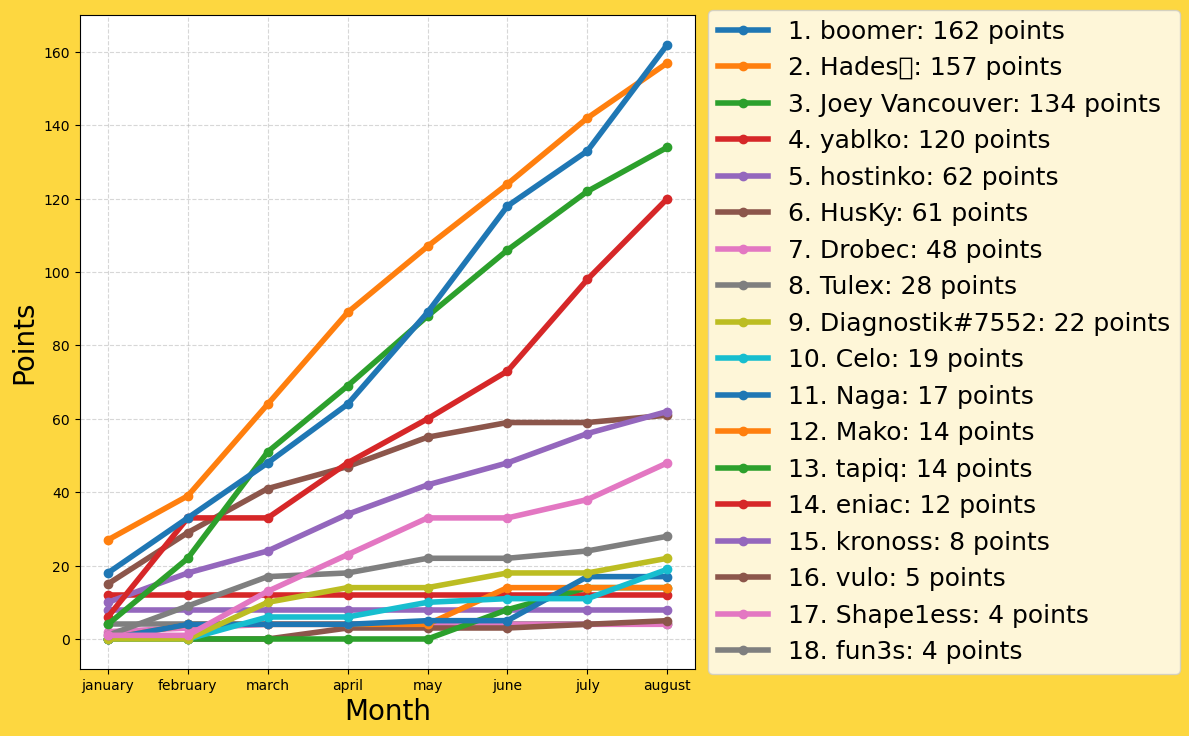

In [16]:
import matplotlib.pyplot as plt
cumulative = rankings_year.iloc[:, 1:-1].cumsum(axis=1)
cumulative["name"] = rankings_year["name"]

fig, ax = plt.subplots(figsize=(12, 7.75), facecolor="#fdd740")

for i, row in cumulative.iterrows():
    ax.plot(rankings_year.iloc[:, 1:-1].columns, row.values[0:-1], 'o-', label=f"{i}. {row['name']}: {row.values[-2]} points", linewidth=4, zorder=100-i)
    # Annotate name at the last point
    #plt.text(x=4.3, y=row.values[-2], s=row['name'],
    #         va='center', ha='left', fontsize=12)
    
#names_points = cumulative.groupby(cumulative.columns[-2])['name'].agg(', '.join).reset_index()
#for i, row in names_points.iterrows():
#    plt.text(x=1.1, y=row.values[-2], s=row['name'] + f": {row.values[-2]}",
#             va='center', ha='left', fontsize=12, rotation=0, rotation_mode='anchor')

#plt.title('Arcade Watch GtG League Points Over Time')
plt.xlabel('Month', fontsize=20)
plt.ylabel('Points', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=18)
plt.tight_layout()
plt.show()

c:\Users\peter\.conda\envs\gtg\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\peter\.conda\envs\gtg\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


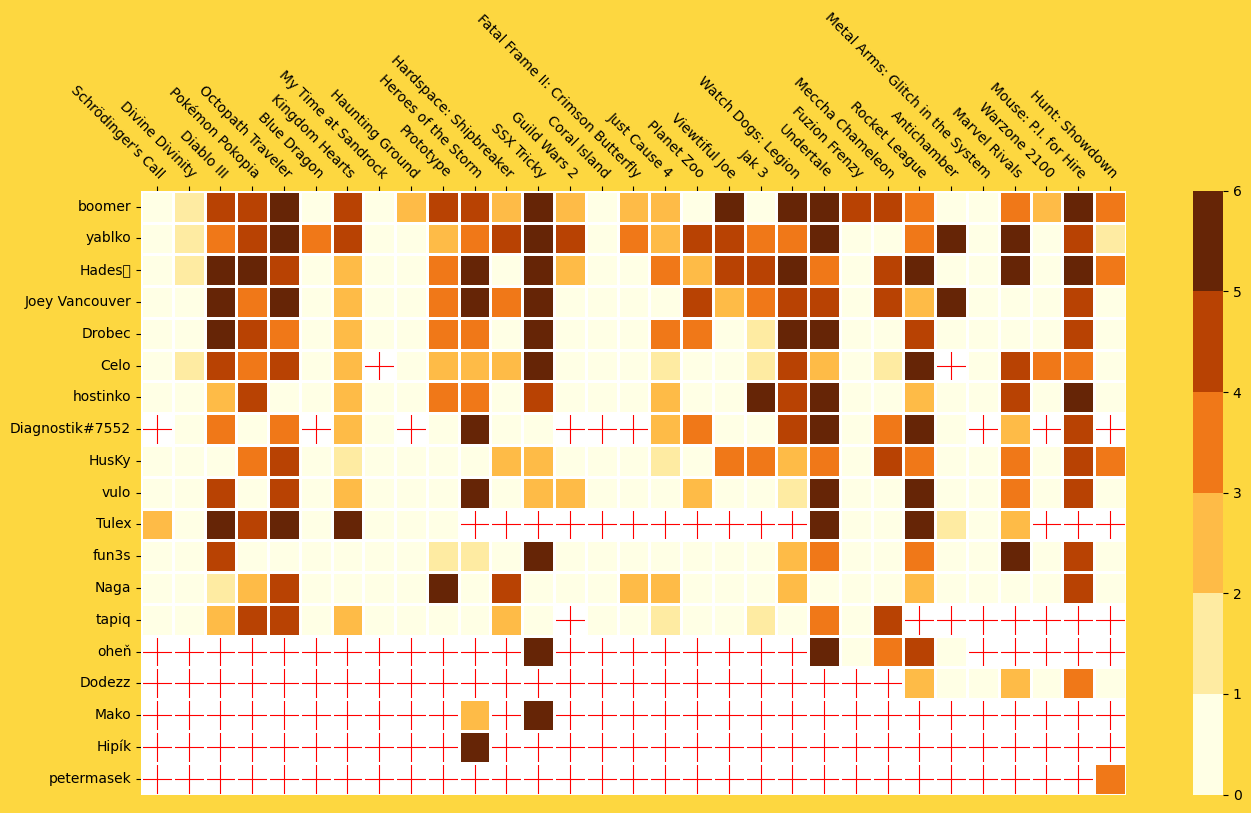

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

matrix_df = df.pivot(index="name", columns="day", values="score")

# 3. Reorder the matrix using the sorted names
matrix_ordered = matrix_df.loc[df_final.name]

# Set up the figure size based on your matrix shape
plt.figure(figsize=(15, 8), facecolor="#fdd740")

segmented_cmap = plt.get_cmap("YlOrBr", 6)

# Plot the heatmap
sns.heatmap(
    matrix_ordered, 
    cmap=segmented_cmap,        # GitHub-style green shading
    linewidths=2,         # Spacing between the blocks ("dots")
    linecolor="white",    # Grid line color matching the background
    square=True,          # Forces cells to be perfectly square
    cbar=True,            # Set to False if you don't want the color intensity scale
    mask=matrix_ordered.isnull(), # Automatically leaves NaNs as empty/white space
    zorder=10
)

plt.xlabel(None)
plt.ylabel(None)
new_labels = new_games_df.loc[matrix_ordered.columns, 'game']

# 2. Apply the new labels to the current x-ticks positions
plt.xticks(
    ticks=np.arange(len(matrix_ordered.columns))+0.5, 
    labels=new_labels, 
    rotation=-45, 
    rotation_mode='anchor',
    ha="right"
)

ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.tick_params(axis="x", top=True, bottom=False, labeltop=True, labelbottom=False)

plt.grid(color='red')

plt.tight_layout()
plt.show()